[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mpinaz/Thesis/blob/main/Plots_of_Catalog.ipynb)

# Librerie

In [1]:
!pip install obspy contextily

In [2]:
!git clone https://github.com/Mpinaz/Thesis.git

fatal: destination path 'Thesis' already exists and is not an empty directory.


In [2]:
from obspy import read, Stream, UTCDateTime
from obspy.clients.fdsn import Client
from obspy.clients.fdsn.header import FDSNNoDataException

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display
import plotly.graph_objects as go

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit

import numpy as np
import pandas as pd
import pickle as pk
from collections import defaultdict

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# KVG Catalog

## Stations

### Retrieve Coordinates

In [5]:
client = Client("https://geofon.gfz-potsdam.de")
tstart = UTCDateTime("2015-07-01 00:00:00")
tend   = UTCDateTime("2016-07-31 00:00:00")

inv = client.get_stations(network="X9",  starttime=tstart, endtime=tend, channel="*HN")
# print(inv)
nsta = np.shape(inv)[1]

# stla = np.zeros(nsta)
# stlo = np.zeros(nsta)
coordinates_for_station = {}
stname = []
lons, lats = [],[]
for i in range(0,nsta):
    coordinates_for_station[inv[0][i].code] = [inv[0][i].latitude,inv[0][i].longitude]
    lons.append(inv[0][i].longitude)
    lats.append(inv[0][i].latitude)

### Plot of the area

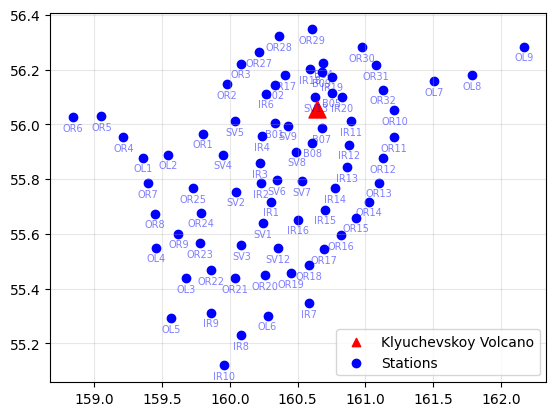

In [6]:
Klyuchevskoy = {"lon" : 56.056,
                "lat" : 160.642}

for St in list(coordinates_for_station.keys()):

  lat, lon = coordinates_for_station[St][0], coordinates_for_station[St][1]
  plt.scatter(lon, lat, marker="o", color="blue")
  plt.annotate(St, (lon, lat), textcoords="offset points", xytext=(0, -10), ha="center", fontsize=7, color="blue", alpha = 0.5)

plt.scatter(Klyuchevskoy["lat"], Klyuchevskoy["lon"], marker="^", s=150, color="red")

plt.scatter([], [], marker="^", color="red", label="Klyuchevskoy Volcano")
plt.scatter([], [], marker="o", color="blue", label="Stations")

plt.legend()
plt.grid("on",alpha=0.3)
plt.savefig("Stazioni in relazione al vulcano.png")
plt.show()

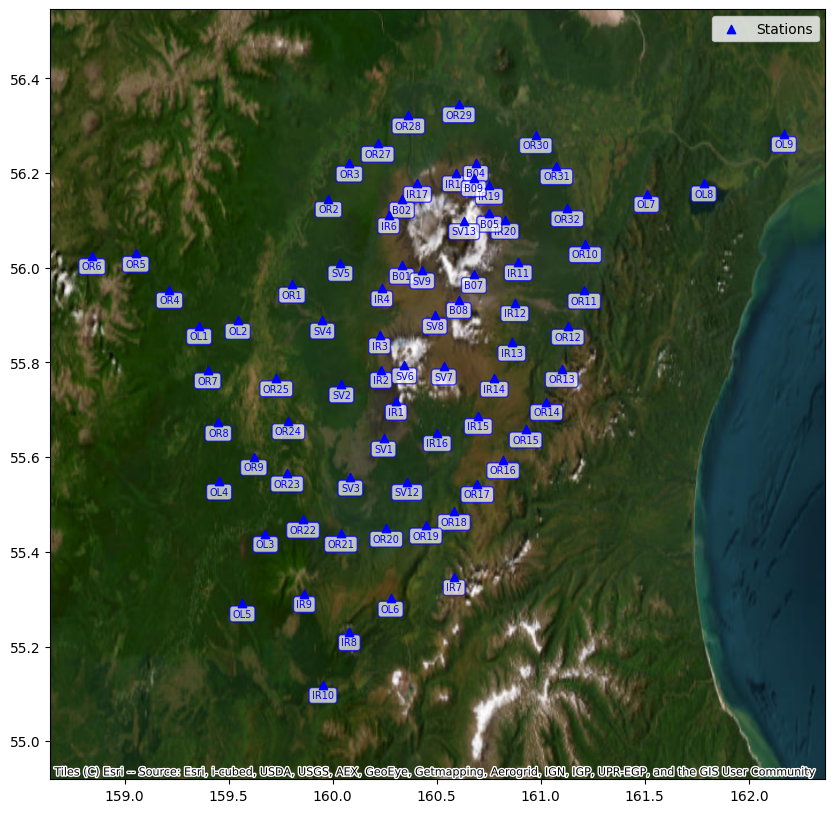

In [7]:
import contextily as cx

fig, ax = plt.subplots(figsize=(10, 10))

for St, (lat, lon) in coordinates_for_station.items():
    ax.scatter(lon, lat, marker="^", color="blue", zorder=5)
    ax.annotate(St, (lon, lat), textcoords="offset points",
            xytext=(0, -10), ha="center", fontsize=7, color="blue",
            bbox=dict(boxstyle="round", facecolor="white", edgecolor="blue", alpha=0.7))

ax.scatter([], [], marker="^", color="blue", label="Stations")
ax.legend()

margin = 0.2
ax.set_xlim(min(lons)-margin, max(lons)+margin)
ax.set_ylim(min(lats)-margin, max(lats)+margin)

cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.Esri.WorldImagery)
plt.show()

## Catalog

In [8]:
catalog = pd.read_csv(
    '/content/Thesis/KVG_catalog.txt',
    sep=',',
    header=None,
    names=['time', 'lat', 'lon', 'depth_km', 'mag'],
)
catalog['time'] = pd.to_datetime(catalog['time'])
catalog['index'] = [f"Event {i}" for i in range(1,len(catalog)+1)]
catalog = catalog.set_index("index")


print(f"Loaded {len(catalog)} events")
print(f"Time range: {catalog['time'].min()} to {catalog['time'].max()}")
print(f"Magnitude range: {catalog['mag'].min():.1f} – {catalog['mag'].max():.1f}")
catalog.head()

Loaded 11209 events
Time range: 2015-08-03 14:56:47.810000+00:00 to 2016-07-04 21:46:56.760000+00:00
Magnitude range: 0.0 – 3.1


,time,lat,lon,depth_km,mag
index,,,,,
Event 1,2015-08-03 14:56:47.810000+00:00,56.051729,160.607292,30.49,1.42
Event 2,2015-08-05 02:33:26.280000+00:00,56.027136,160.655599,31.35,2.01
Event 3,2015-08-06 02:11:34.860000+00:00,56.038220,160.563005,29.36,1.97
Event 4,2015-08-06 08:01:51.920000+00:00,56.051261,160.605957,29.73,1.96
Event 5,2015-08-06 10:07:05.340000+00:00,56.067623,160.550732,43.55,1.86


## Phase Data

In [9]:
stations_for_event = {}
Event_per_station = {}
i=0
with open("/content/Thesis/KVG_phase_data.txt", "r", encoding="UTF-8") as f:
    date = -1
    line = f.readline()

    while line != "":
        check = line[:2]
        match check:
            case "X9":
                datas = line.split(",")
                #                                              NOME STAZIONE     P TIME   S TIME
                stations_for_event.setdefault(f"Event {i}", {})[datas[0][3:]] = (datas[1],datas[2])
                Event_per_station.setdefault(datas[0][3:], []).append(f"Event {i}")

            case "D0":
                pass

            case _:
                date = line.split(",")[0]
                i+=1
        line = f.readline()

# Number Of events Over Time

/tmp/ipykernel_1269/3970050378.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  counts = catalog["time"].dt.to_period("W").value_counts()


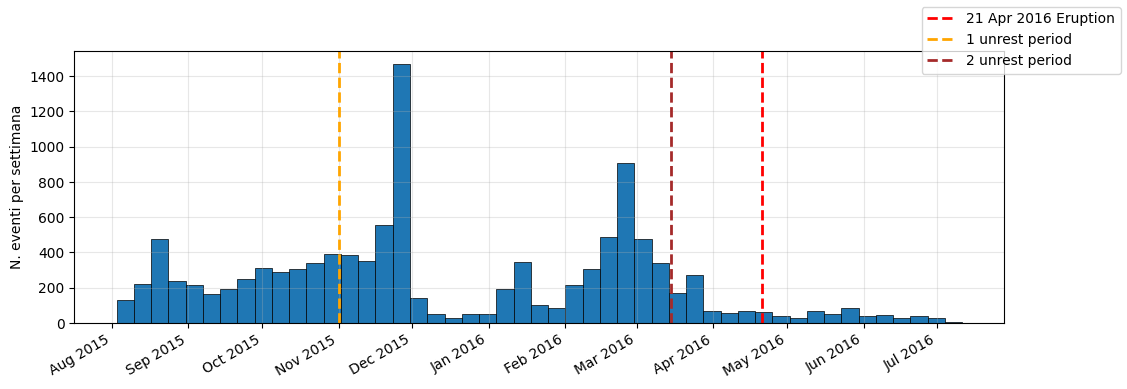

In [36]:
counts = catalog["time"].dt.to_period("W").value_counts()
counts.index = counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))

ax.xaxis.set_major_locator(mdates.MonthLocator())          # un tick al mese
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

ax.bar(counts.index, counts.values, width=7, align="edge", edgecolor="black", linewidth=0.5)


Lines = [pd.Timestamp("2016-04-21"), pd.Timestamp("2015-11-1"), pd.Timestamp("2016-03-15")]
labels = ["21 Apr 2016 Eruption", "1 unrest period", "2 unrest period"]
colors = ["red", "orange", "brown"]
for l, e, c in zip(Lines, labels, colors):
  ax.axvline(l, linestyle="--", linewidth=2, label=e, color=c)
ax.grid("on", alpha = 0.3)

ax.set_ylabel("N. eventi per settimana")
fig.legend()

plt.savefig("Number_of_Events_Over_Time.png")

# Magnitude of events over time

Text(0, 0.5, 'Magnitude')

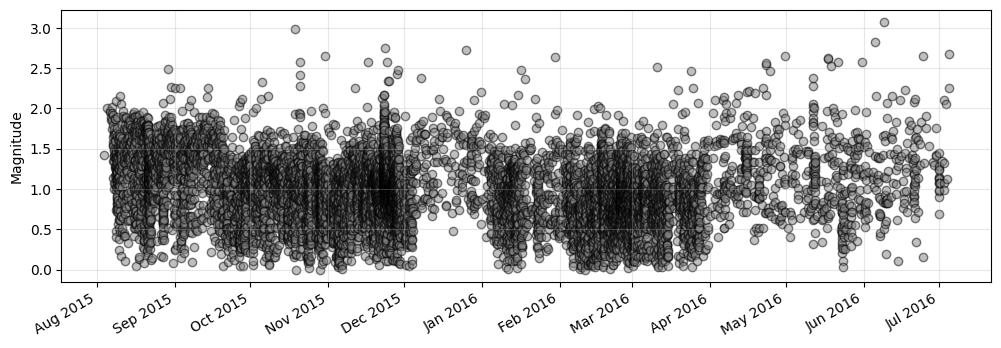

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.xaxis.set_major_locator(mdates.MonthLocator())          # un tick al mese
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()

ax.scatter(catalog["time"], catalog["mag"], marker="o", color="grey", alpha = 0.5, edgecolor = "black")
ax.grid("on", alpha = 0.3)
ax.set_ylabel("Magnitude")

# Divisione del Catalog secondo geografia

In [ ]:
Squares = {
    "TOL" : {"lat" : (55.75, 55.90), "lon" : (160.25, 160.42), "depth" : (-5, 25), "color" : "red"},
    "Shallow KLU" : {"lat" : (56, 56.15), "lon" : (160.60, 160.72), "depth" : (-5, 20), "color" : "blue"},
    "Deep KLU" : {"lat" : (55.95, 56.10), "lon" : (160.55, 160.70), "depth" : (25, 50), "color" : "green"},
    "USH" : {"lat" : (56.05, 56.18), "lon" : (160.40, 160.55), "depth" : (-5, 25), "color" : "orange"}}

lab = pd.Series("Other", index=catalog.index)
for name, b in Squares.items():
    m = (catalog.lat.between(*b["lat"]) &
         catalog.lon.between(*b["lon"]) &
         catalog.depth_km.between(*b["depth"]))
    lab[m] = name
catalog["group"] = lab

fig = go.Figure()


for name in ["Other"] + list(Squares):
    sub = catalog[catalog.group == name]
    fig.add_trace(go.Scatter3d(
        x=sub.lat, y=sub.lon, z=sub.depth_km,
        mode="markers", name=name,
        marker=dict(size=2,
                    color="lightgray" if name == "Other" else Squares[name]["color"],
                    opacity=0.35 if name == "Other" else 0.9)))

In [ ]:
def box_edges(lat, lon, dep):
    x0, x1 = lat; y0, y1 = lon; z0, z1 = dep
    v = [(x0,y0,z0),(x1,y0,z0),(x1,y1,z0),(x0,y1,z0),
         (x0,y0,z1),(x1,y0,z1),(x1,y1,z1),(x0,y1,z1)]
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),
             (0,4),(1,5),(2,6),(3,7)]
    xs, ys, zs = [], [], []
    for i, j in edges:
        xs += [v[i][0], v[j][0], None]
        ys += [v[i][1], v[j][1], None]
        zs += [v[i][2], v[j][2], None]
    return xs, ys, zs

In [ ]:
for name, b in Squares.items():
    xs, ys, zs = box_edges(b["lat"], b["lon"], b["depth"])
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs, mode="lines",
        line=dict(color=b["color"], width=3),
        showlegend=False, hoverinfo="skip"))

fig.update_layout(scene=dict(
    xaxis_title="Latitude (°)", yaxis_title="Longitude (°)",
    zaxis=dict(title="Depth (km)", autorange="reversed")))
fig.show()

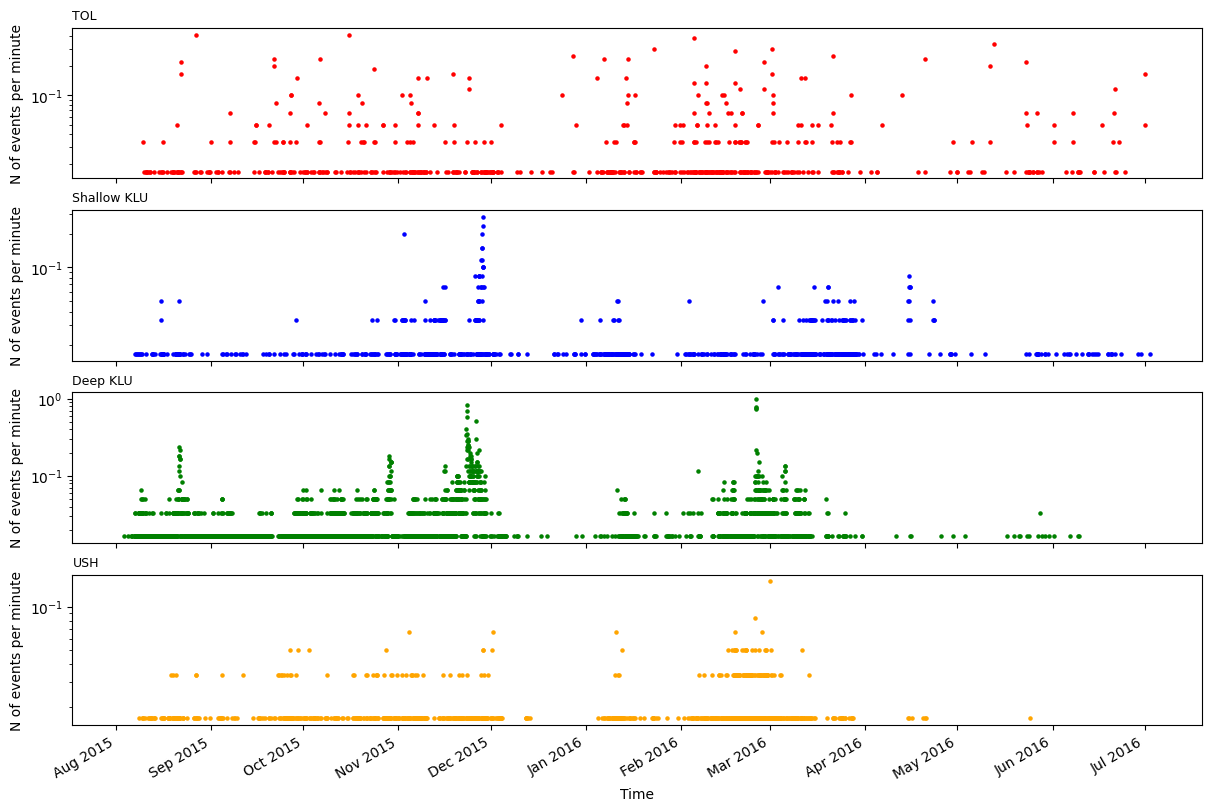

In [ ]:
groups = list(Squares.keys())

bin_min = 60  # ampiezza bin in minuti; eventi/minuto = conteggio / bin_min
freq = f"{bin_min} min"

fig, axes = plt.subplots(len(groups), 1, figsize=(12, 8),
                         sharex=True, constrained_layout=True)

for ax, g in zip(axes, groups):
    sub = catalog[catalog.group == g]
    counts = sub.set_index("time").resample(freq).size()
    rate = counts / bin_min
    ax.scatter(rate.index, rate.values, s=5, color = Squares[g]["color"])

    ax.set_yscale("log")
    ax.set_ylabel("N of events per minute")
    ax.set_title(g, loc="left", fontsize=9)

    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

fig.autofmt_xdate()
axes[-1].set_xlabel("Time")
plt.show()

## 3D

In [ ]:
Latitudini = catalog["lat"].values
Longitudini = catalog["lon"].values
Profondità = catalog["depth_km"].values

fig = go.Figure(data=[go.Scatter3d(
    x = Latitudini,
    y = Longitudini,
    z = Profondità,
    mode='markers',
    marker=dict(
        size=2,
        color='black')
    )])

fig.update_layout(
    scene=dict(
        zaxis=dict(autorange="reversed")))

fig.show()

# Import Dataset

In [3]:
# 90000 Registrations Pre Eruption
with open("/content/drive/MyDrive/Datasets/Pre_Events.pkl", "rb") as f:
    pre = pk.load(f)

# 4649 Registrations Post Eruption
with open("/content/drive/MyDrive/Datasets/Post_Events.pkl", "rb") as f:
    post = pk.load(f)

In [4]:
pre_events = defaultdict(list)
post_events = defaultdict(list)
pre_stations = defaultdict(list)
post_stations = defaultdict(list)

for St, E, Reg in pre:
    pre_events[E].append((St, E, Reg))
    pre_stations[St].append((St, E, Reg))

for St, E, Reg in post:
    post_events[E].append((St, E, Reg))
    pre_stations[St].append((St, E, Reg))

# Single Event Analysis

In [56]:
All_events = list(pre_events.keys()) + list(post_events.keys())
np.random.shuffle(All_events)
Event = All_events[0]

Label = "Post" if Event in set(post_events.keys()) else "Pre"

Data = pre_events[Event] if Label == "Pre" else post_events[Event]

for _, _, st in Data:
  for tr in st:

    tr.detrend("demean")
    tr.detrend("linear")

    tr.filter(
        "bandpass",
        freqmin=1,
        freqmax=20,
        corners=4,
        zerophase=True)

Pre Eruption, Event 2461
Recorded by 8 different stations


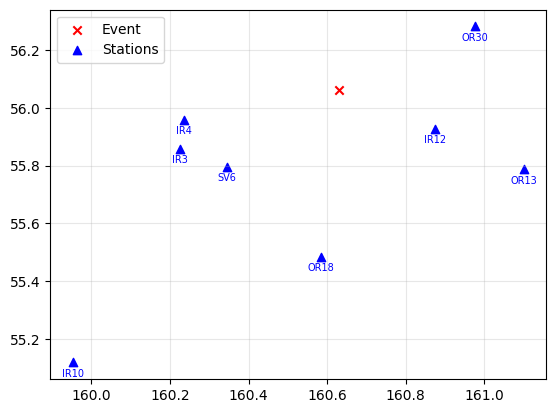

In [58]:
Stations_That_Recorded = set(i[0] for i in Data)
for St in Stations_That_Recorded:

  lat, lon = coordinates_for_station[St][0], coordinates_for_station[St][1]
  plt.scatter(lon, lat, marker="^", color="blue")
  plt.annotate(St, (lon, lat), textcoords="offset points", xytext=(0, -10), ha="center", fontsize=7, color="blue")

plt.scatter(catalog.loc[Event, "lon"], catalog.loc[Event, "lat"], marker="x", color="red")

plt.scatter([], [], marker="x", color="red", label="Event")
plt.scatter([], [], marker="^", color="blue", label="Stations")
print(f"{Label} Eruption, {Event}\nRecorded by {len(Stations_That_Recorded)} different stations")
plt.legend()
plt.grid("on",alpha=0.3)
plt.show()

Stazione OR30



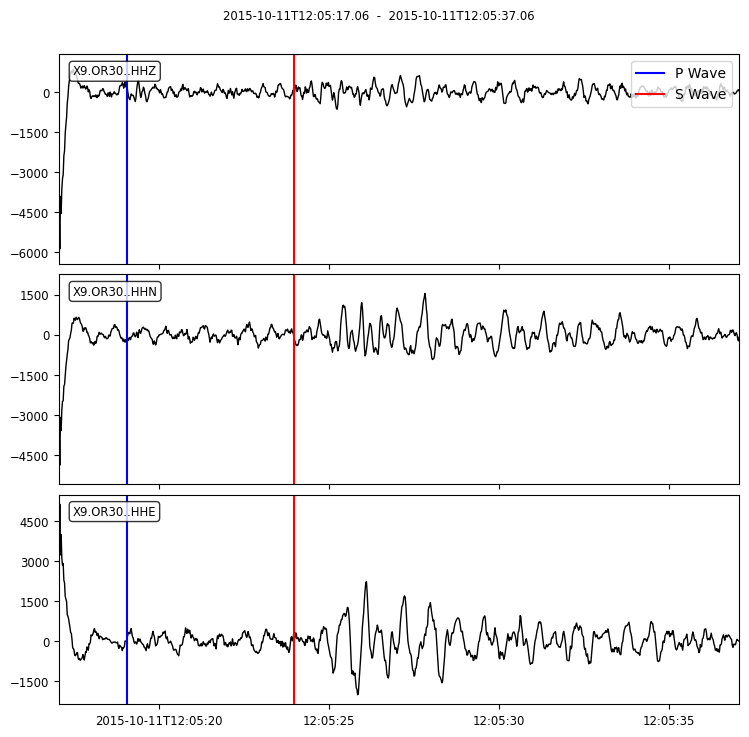

In [60]:
Plotting = Data[np.random.randint(0, len(Data))-1]
Station_Name = Plotting[0]
P_Wave = UTCDateTime(stations_for_event[Event][Station_Name][0]).datetime
S_Wave = UTCDateTime(stations_for_event[Event][Station_Name][1]).datetime

print(f"Stazione {Plotting[0]}\n")
fig = Plotting[-1].plot(show=False)
fig.subplots_adjust(hspace=0.05)
for i in range(len(fig.axes)):
  ax = fig.axes[i]
  ax.axvline(P_Wave, color='blue', label = "P Wave")
  ax.axvline(S_Wave, color='red', label = "S Wave")
fig.axes[0].legend(loc = "upper right")
display(fig)

# Single Station Analysis

In [10]:
All_stations = list(pre_stations.keys())
np.random.shuffle(All_stations)
Station = All_stations[0]

All_events = pre_stations[Station] + post_stations[Station]
Events_Registred = set(i[1] for i in All_events)

/tmp/ipykernel_6542/3778485814.py:9: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(lat, lon, marker="x", color=color, alpha=0.5,


La stazione ha misurato 498 Eventi: Pre = 437; Post = 61


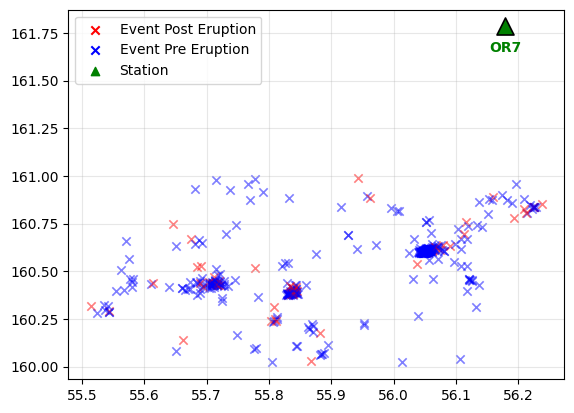

In [23]:
check = set(post_events.keys())
lat_st, lon_st = coordinates_for_station[St][0], coordinates_for_station[St][1]
Post_num = 0

for E in Events_Registred:
    lat, lon = catalog.loc[E, "lat"], catalog.loc[E, "lon"]
    color = "red" if E in check else "blue"
    Post_num += 1 if color == "red" else 0
    plt.scatter(lat, lon, marker="x", color=color, alpha=0.5,
                linewidths=1.2, edgecolors="black")

print(f"La stazione ha misurato {len(Events_Registred)} Eventi: Pre = {len(Events_Registred) - Post_num}; Post = {Post_num}")


plt.scatter(lat_st, lon_st, marker="^", color="green",
            s=150, edgecolors="black", linewidths=1.2, zorder=5)
plt.annotate(Station, (lat_st, lon_st), textcoords="offset points",
             xytext=(0, -18), ha="center", fontsize=10,
             fontweight="bold", color="green", zorder=6)

# Legenda
plt.scatter([], [], marker="x", color="red", label="Event Post Eruption")
plt.scatter([], [], marker="x", color="blue", label="Event Pre Eruption")
plt.scatter([], [], marker="^", color="green", label="Station")

plt.legend()
plt.grid("on", alpha=0.3)
plt.show()

Stazione OR7
Event 7371: Pre Eruption


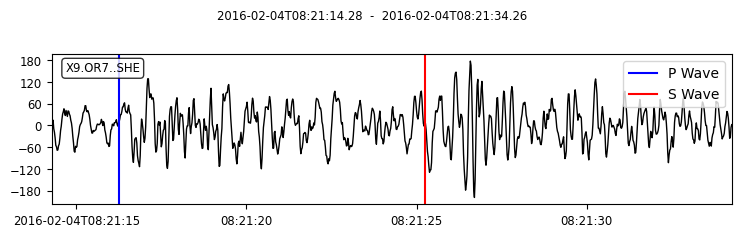

In [38]:
np.random.shuffle(All_events)
Obj = All_events[0]
Data = Obj[-1]
Event = Obj[1]
Label = "Post" if Event in check else "Pre"


for tr in Data:
  tr.detrend("demean")
  tr.detrend("linear")

  tr.filter(
      "bandpass",
      freqmin=1,
      freqmax=20,
      corners=4,
      zerophase=True)

Plotting = Data[-1]
Station_Name = Plotting[0]

P_Wave = UTCDateTime(stations_for_event[Event][Station][0]).datetime
S_Wave = UTCDateTime(stations_for_event[Event][Station][1]).datetime

print(f"Stazione {Station}\n{Event}: {Label} Eruption")
fig = Plotting.plot(show=False)
fig.subplots_adjust(hspace=0.05)
for i in range(len(fig.axes)):
  ax = fig.axes[i]
  ax.axvline(P_Wave, color='blue', label = "P Wave")
  ax.axvline(S_Wave, color='red', label = "S Wave")
fig.axes[0].legend(loc = "upper right")
display(fig)